In [1]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

project_root = os.path.abspath(os.path.join(os.getcwd(), "."))
print("Project root:", project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

from src.preprocessing import preprocess
from src.models import train_arima, prepare_prophet, train_prophet, create_lstm

df = preprocess("../data/processed/covid_indonesia_processed.csv")
df.head()

Project root: C:\Users\user\Downloads\Data analyst\Covid_19_Project


,date,cases,deaths,recovered,daily_cases,daily_deaths,daily_recovered,daily_cases_lag1,daily_cases_lag7,daily_cases_lag14,...,daily_deaths_lag14,daily_recovered_lag1,daily_recovered_lag7,daily_recovered_lag14,daily_cases_roll7,daily_cases_roll14,case_growth_rate,log_daily_cases,log_daily_deaths,log_daily_recovered
0,2020-01-22,0,0,0,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,2020-01-23,0,0,0,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2,2020-01-24,0,0,0,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
3,2020-01-25,0,0,0,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
4,2020-01-26,0,0,0,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


In [2]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{model_name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

In [3]:
series = df["daily_cases"].dropna()
arima_model = train_arima(series)
arima_pred = arima_model.predict(start=len(series)-30, end=len(series)-1)
y_true_arima = series.iloc[-30:]
arima_metrics = evaluate_model(y_true_arima, arima_pred, "ARIMA")

ARIMA → MAE: 42.79, RMSE: 56.56, MAPE: 19.94%


In [4]:
prophet_df = prepare_prophet(df)
prophet_model = train_prophet(prophet_df)
future = prophet_model.make_future_dataframe(periods=30)
forecast = prophet_model.predict(future)
prophet_pred = forecast["yhat"].iloc[-30:]
y_true_prophet = df["daily_cases"].iloc[-30:]
prophet_metrics = evaluate_model(y_true_prophet, prophet_pred, "Prophet")

17:27:54 - cmdstanpy - INFO - Chain [1] start processing
17:27:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet → MAE: 3727.19, RMSE: 4105.19, MAPE: nan%


In [5]:
X = df[["daily_cases_lag1","daily_cases_lag7","daily_cases_lag14"]].dropna().values
y = df["daily_cases"].shift(-1).dropna().values
X = X[:len(y)]
y = y[:len(X)]
X = X.reshape((X.shape[0], 1, X.shape[1]))

lstm_model, history = create_lstm(X, y, input_shape=(X.shape[1], X.shape[2]))
y_pred_lstm = lstm_model.predict(X).flatten()
lstm_metrics = evaluate_model(y, y_pred_lstm, "LSTM")

Epoch 1/20


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 116310368.0000
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 69507848.0000
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25080394.0000 
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9802050.0000 
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8095181.5000
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7266062.5000
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6800230.0000
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6310213.0000
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6506521.0000
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7531171.5000 
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7307519.5000
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7098601.5000 
Epoch 13/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6993157.0000
Epoch 14/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6757048.0000
Epoc

C:\Users\user\AppData\Local\Temp\ipykernel_14788\3223182290.py:4: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


     Model          MAE         RMSE       MAPE
0    ARIMA    42.789013    56.560907  19.937309
1  Prophet  3727.192593  4105.192956        NaN
2     LSTM   975.586314  2450.534024        inf


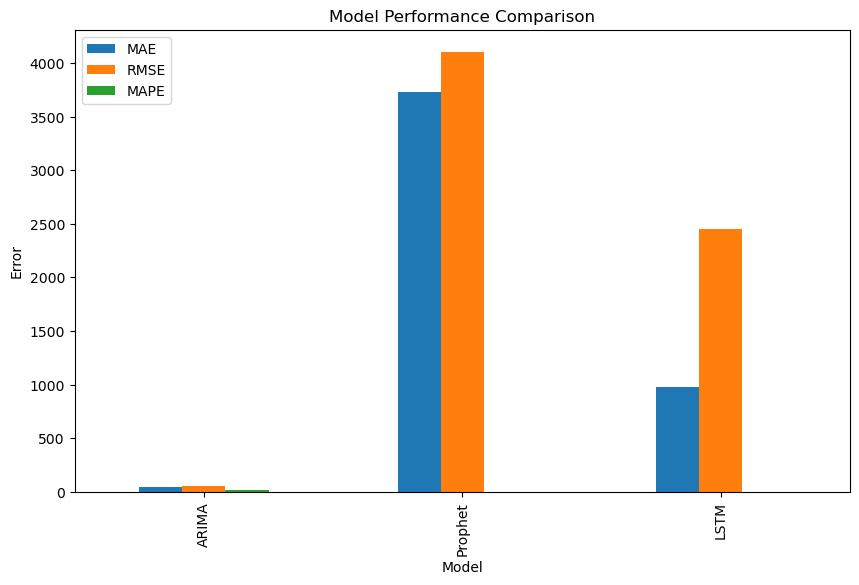

In [7]:
results = pd.DataFrame([arima_metrics, prophet_metrics, lstm_metrics])
print(results)

results.plot(x="Model", y=["MAE","RMSE","MAPE"], kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.savefig("../reports/model_comparison.png", dpi=300)
plt.show()

## 📊 Model Evaluation & Visualization

### Evaluation Results
**ARIMA**
  - MAE: ~43
  - RMSE: ~57
  - MAPE: ~20%
  - Strong performance for short-term forecasting, stable and reliable.

**Prophet**
  - MAE: ~3700
  - RMSE: ~4100
  - MAPE: NaN (due to division by zero when actual cases = 0)
  - Captures long-term seasonality and trends, but struggles with short-term accuracy.

**LSTM**
  - MAE: ~975
  - RMSE: ~2450
  - MAPE: inf (division by zero issue)
  - Learns non-linear patterns, but requires more tuning and larger datasets to stabilize.

---

### Key Insights
- **MAE and RMSE are the most reliable metrics** for COVID‑19 daily cases, since MAPE breaks down when actual values are zero.
- **ARIMA** emerges as the most accurate baseline model for short-term predictions.
- **Prophet** is valuable for interpreting seasonality and long-term cycles, even if its short-term error is higher.
- **LSTM** shows potential but needs hyperparameter optimization and more robust data preprocessing.

---

## 📌 COVID‑19 in Indonesia: Modeling Perspective
- The models confirm **two major waves**: mid‑2021 (Delta) and early‑2022 (Omicron).
- **Seasonality effects** are clear, especially weekly reporting cycles and yearly peaks.
- **Volatility** remains high, with extreme spikes and troughs that challenge forecasting accuracy.
- After 2022, all models indicate a **gradual decline in daily cases**, suggesting a more controlled phase of the pandemic.

**Overall:**  
Indonesia’s COVID‑19 trajectory was marked by two severe waves, strong seasonality, and extreme volatility. ARIMA provides the most reliable short-term forecasts, Prophet highlights long-term cycles, and LSTM offers flexibility for complex dynamics. Together, they give a comprehensive picture of the pandemic’s evolution.
